![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

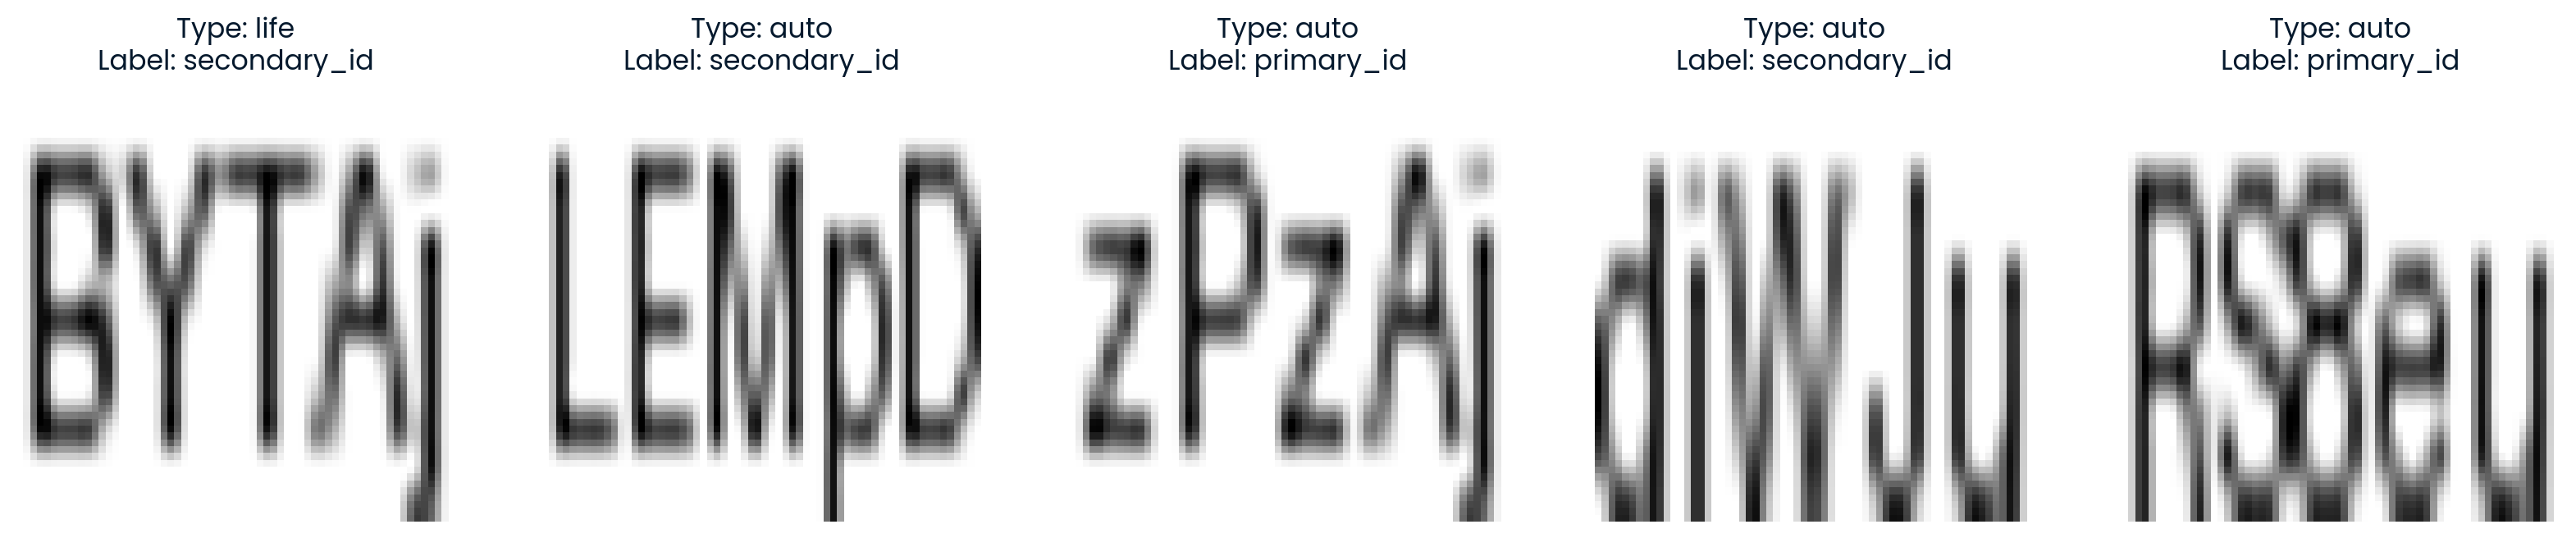

In [13]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

In [14]:
# Mendefinisikan class OCRModel
class OCRModel(nn.Module):
    def __init__(self, num_types, num_classes):
        super(OCRModel, self).__init__()
        
        # Mendefinisikan layer gambar: inisialisasi layer konvolusi & menambahkan pooling
        self.image_layer = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
        
        # Menerapkan perataan fitur (flattening)
        self.flatten = nn.Flatten()
        
        # Mendefinisikan layer tipe dokumen: menambahkan fully-connected layer
        self.type_layer = nn.Sequential(
            nn.Linear(in_features=num_types, out_features=16),
            nn.ReLU()
        )
        
        # Membuat classifier untuk prediksi akhir
        # Output gambar yang diratakan (32 channels * 16 * 16 = 8192) + 16 fitur dari layer tipe
        self.classifier = nn.Sequential(
            nn.Linear(in_features=8192 + 16, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=num_classes)
        )

    # Mendefinisikan alur maju (forward pass)
    def forward(self, image, doc_type):
        # Sesuaikan bentuk gambar untuk layer konvolusi
        image = image.view(-1, 1, 64, 64)
        
        # Ekstraksi fitur gambar
        img_features = self.image_layer(image)
        img_features = self.flatten(img_features)
        
        # Ekstraksi fitur tipe dokumen
        type_features = self.type_layer(doc_type)
        
        # Gabungkan kedua fitur
        combined = torch.cat((img_features, type_features), dim=1)
        
        # Hasilkan prediksi
        return self.classifier(combined)

In [15]:
# Menyiapkan DataLoader (membagi data ke dalam batch berukuran 32)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Mengambil jumlah tipe dokumen dan jumlah kelas label dari dataset
num_types = len(dataset.type_mapping)
num_classes = len(dataset.label_mapping)

# Inisialisasi model OCR
model = OCRModel(num_types, num_classes)

In [16]:
# Mendefinisikan optimizer dan fungsi loss (kerugian)
# Menggunakan Adam sebagai algoritma optimasi
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Menggunakan Cross-Entropy untuk fungsi loss
criterion = nn.CrossEntropyLoss()

In [17]:
# Melatih model (iterasi pada dataset selama dua epoch)
for epoch in range(2):
    model.train() # Mengubah model ke mode pelatihan
    running_loss = 0.0
    
    for i, data in enumerate(train_loader):
        features, labels = data
        images = features[0]
        doc_types = features[1].float() # Pastikan tipe dokumen berupa float
        
        # Kosongkan gradient sebelumnya
        optimizer.zero_grad()
        
        # Hitung tebakan model
        outputs = model(images, doc_types)
        
        # Hitung kesalahan (loss)
        loss = criterion(outputs, labels)
        
        # Hitung gradient (perambatan balik / backward pass)
        loss.backward()
        
        # Perbarui bobot model
        optimizer.step()
        
        # Simpan total loss untuk ditampilkan
        running_loss += loss.item()
        
    # Tampilkan rata-rata loss setiap selesai 1 epoch
    print(f"Epoch {epoch+1}/2 - Rata-rata Loss: {running_loss / len(train_loader):.4f}")

Epoch 1/2 - Rata-rata Loss: 0.9672
Epoch 2/2 - Rata-rata Loss: 0.7147


In [18]:
# Mengubah model ke mode evaluasi
model.eval()

# Mengambil satu batch data
dataiter = iter(train_loader)
features, labels = next(dataiter)
images = features[0]
doc_types = features[1].float()

# Meminta model melakukan prediksi tanpa menghitung gradient
with torch.no_grad():
    outputs = model(images, doc_types)
    _, predicted = torch.max(outputs, 1)

# Menampilkan 5 hasil pertama
print("Label Asli: ", labels[:5].tolist())
print("Tebakan Model:", predicted[:5].tolist())

Label Asli:  [1, 1, 0, 1, 1]
Tebakan Model: [1, 1, 1, 1, 1]


In [19]:
# Menyimpan bobot model
torch.save(model.state_dict(), 'ocr_model.pth')
print("Model berhasil disimpan!")

Model berhasil disimpan!
